Importing libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

read the README

In [5]:
with open("README.txt", "r") as file:
    print(file.read())

Summary

This dataset (ml-latest-small) describes 5-star rating and free-text tagging activity from [MovieLens](http://movielens.org), a movie recommendation service. It contains 100836 ratings and 3683 tag applications across 9742 movies. These data were created by 610 users between March 29, 1996 and September 24, 2018. This dataset was generated on September 26, 2018.

Users were selected at random for inclusion. All selected users had rated at least 20 movies. No demographic information is included. Each user is represented by an id, and no other information is provided.

The data are contained in the files `links.csv`, `movies.csv`, `ratings.csv` and `tags.csv`. More details about the contents and use of all these files follows.

This is a *development* dataset. As such, it may change over time and is not an appropriate dataset for shared research results. See available *benchmark* datasets if that is your intent.

This and other GroupLens data sets are publicly available for down

Loading all CSV files

In [6]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("tags.csv")
links = pd.read_csv("links.csv")

Understanding dataset

In [7]:
movies.head()
ratings.head()
tags.head()
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [8]:
movies.info()
ratings.info()
tags.info()
links.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userId     3683 non-null   int64 
 1   movieId    3683 non-nul

Data cleaning

In [9]:
movies.isnull().sum()
ratings.isnull().sum()
tags.isnull().sum()
links.isnull().sum()

movieId    0
imdbId     0
tmdbId     8
dtype: int64

Converting timestamp to readable date

In [10]:
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
tags['timestamp'] = pd.to_datetime(tags['timestamp'], unit='s')

Merge movies + ratings

In [13]:
movies_ratings = pd.merge(
    ratings,
    movies,
    on='movieId',
    how='left'
)

Merge tags

In [14]:
movies_ratings_tags = pd.merge(
    movies_ratings,
    tags,
    on=['movieId', 'userId'],
    how='left'
)

merge links

In [15]:
final_df = pd.merge(
    movies_ratings_tags,
    links,
    on='movieId',
    how='left'
)

final dataset check

In [16]:
final_df.head()
final_df.info()
final_df.shape

<class 'pandas.core.frame.DataFrame'>
Int64Index: 102677 entries, 0 to 102676
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   userId       102677 non-null  int64         
 1   movieId      102677 non-null  int64         
 2   rating       102677 non-null  float64       
 3   timestamp_x  102677 non-null  datetime64[ns]
 4   title        102677 non-null  object        
 5   genres       102677 non-null  object        
 6   tag          3476 non-null    object        
 7   timestamp_y  3476 non-null    datetime64[ns]
 8   imdbId       102677 non-null  int64         
 9   tmdbId       102664 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 8.6+ MB


(102677, 10)

Performing EDA

In [17]:
final_df.describe()

,userId,movieId,rating,imdbId,tmdbId
count,102677.000000,102677.000000,102677.000000,1.026770e+05,102664.000000
mean,327.761933,19742.712623,3.514813,3.564994e+05,20476.871289
std,183.211289,35884.400990,1.043133,6.295717e+05,54097.633332
min,1.000000,1.000000,0.500000,4.170000e+02,2.000000
25%,177.000000,1199.000000,3.000000,9.971000e+04,710.000000
50%,328.000000,3005.000000,3.500000,1.188420e+05,6950.000000
75%,477.000000,8366.000000,4.000000,3.172480e+05,11673.000000
max,610.000000,193609.000000,5.000000,8.391976e+06,525662.000000


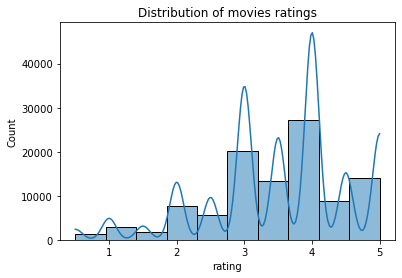

In [18]:
sns.histplot(final_df['rating'], bins=10, kde=True)
plt.title("Distribution of movies ratings")
plt.show()

The rating distribution shows that most users give ratings between 3 and 4 stars. Very few movies receive extremely low ratings. This indicates that user generally rate movies positively, and the dataset is skewed towards higher ratings.

Top rated movies

In [19]:
movies_stats = final_df.groupby('title').agg(
    avg_rating=('rating', 'mean'),
    rating_count=('rating', 'count')
)

top_movies = movies_stats[movies_stats['rating_count'] >= 50] \
.sort_values('avg_rating', ascending=False)
top_movies.head(10)

,avg_rating,rating_count
title,,
Pulp Fiction (1994),4.487603,484
"Shawshank Redemption, The (1994)",4.432602,319
Fight Club (1999),4.402985,268
"Godfather, The (1972)",4.289062,192
Eternal Sunshine of the Spotless Mind (2004),4.278481,158
Cool Hand Luke (1967),4.271930,57
"Godfather: Part II, The (1974)",4.265385,130
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.264706,102
"Departed, The (2006)",4.254386,114


Most popular genres

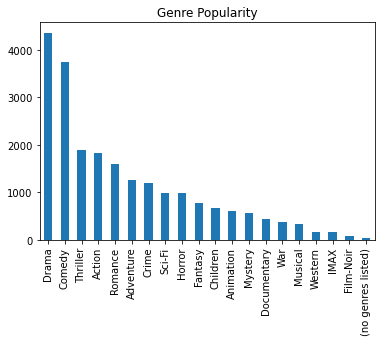

In [20]:
genres = movies['genres'].str.split('|', expand=True)
genre_count = genres.stack().value_counts()

genre_count.plot(kind='bar')
plt.title("Genre Popularity")
plt.show()

The genre popularity graph shows that drama and comedy are the most common genres in the dataset. Thriller and action are also popular. Some genres such as film-noir and western have very few movies, indicating an imbalance in genre distribution

Missing value analysis

In [21]:
final_df.isnull().mean() * 100

userId          0.000000
movieId         0.000000
rating          0.000000
timestamp_x     0.000000
title           0.000000
genres          0.000000
tag            96.614626
timestamp_y    96.614626
imdbId          0.000000
tmdbId          0.012661
dtype: float64

Solution 1 : Movie Recommendation system , The dataset contains explicit ratings given by users to movies. Each user has rated multiple movies, which allows us to understand user preferences. Since movieId connects ratings with movie details, this system is ideal for building a recommendation system. A system that recommends movies to users based on their past ratings and similarities with other users. The columns from this dataset which are important for this solution is userId, movieId, rating, genres. The high level approach for this solution is using collaborative filtering(user based od item based), Identifying similar users or similar movies, Recommending movies with high predicted ratings.

Solution 2 : Personalized genre based recommendation, Each movie is associated with one or more genres, higher than others. This makes it possible to identify a users favourite genres and recommend movies accordingly. Thus using this dataset we can built A personalized recommendation system that suggests movies from genres a user likes the most. Data Columns that can be used are genres, rating, userId. The high level approach for this solution is calculating average ratings per genre for each user, Identifying top genres for a user, Recommend unseen movies from those genres.

Solution 3: Movie Popularity and trend analysis dashboard, The dataset includes timestamps for each rating, which allows analysis of how movie popularity changes overtime. This is useful for identifying trending and evergreen movies. Using this dataset we can built a dashboard that shows: most popular movies, top-rated movies, rating trends overtime. The data columns which can be user are title, rating, timestamp. The high level approach for this solution are aggregate rating by movie and time, visualize trends using graphs and charts.

Solution 4 : Tag based movie search system, This solution is suitable because user provide free text tags that describe movies in terms of theme, mood, story. These tags give additional information beyond genres. Thus we can built a movie search system where users can search movies using keywords such as funny, dark, or based on book. The data columns which can be used from this dataset are tag, movieId, title. The high level approach for this solution is combining all tags related to a movie, match user search keywords with movie tags, return to relevant movies.

Solution 5: Cold start recommendation system, This solution is suitable because new users or newly added movies may not have enough ratings. However genres and tags can still be used to recommend movies in such cases. Thus we can built a recommendation system for users without prior rating history using data columns genres, tags, movieId. The high level approach for this solution is to use content based filtering, recommend movies based on genres and tags